In [1]:
import pandas as pd
import numpy as np

In [2]:
customers = pd.read_csv(r"D:\only dataset\ols\olist_customers_dataset.csv")

geo_location = pd.read_csv(r"D:\only dataset\ols\olist_geolocation_dataset.csv")

order_items = pd.read_csv(r"D:\only dataset\ols\olist_order_items_dataset.csv")

order_payments = pd.read_csv(r"D:\only dataset\ols\olist_order_payments_dataset.csv")

orders = pd.read_csv(r"D:\only dataset\ols\olist_orders_dataset.csv")

order_reviews = pd.read_csv(r"D:\only dataset\ols\olist_order_reviews_dataset.csv")

products = pd.read_csv(r"D:\only dataset\ols\olist_products_dataset.csv")

sellers = pd.read_csv(r"D:\only dataset\ols\olist_sellers_dataset.csv")

product_categories = pd.read_csv(r"D:\only dataset\ols\product_category_name_translation.csv")

In [4]:
##knowing the shape and columns of each table
print('Customers shape:',customers.shape)
print('geo_location :',geo_location.shape)
print('order_items :',order_items.shape)
print('order_payments :',order_payments.shape)
print('orders :',orders.shape)
print('order_reviews :',order_reviews.shape)
print('products :',products.shape)
print('sellers :',sellers.shape)
print('product_Categories :',product_categories.shape)
print('Customers columns:',customers.columns)
print('geo_location columns:',geo_location.columns)
print('order_items columns:',order_items.columns)
print('order_payments columns:',order_payments.columns)
print('orders columns:',orders.columns)
print('order_reviews columns:',order_reviews.columns)
print('products columns:',products.columns)
print('sellers columns:',sellers.columns)
print('product_categories columns:',product_categories.columns)


Customers shape: (99441, 5)
geo_location : (1000163, 5)
order_items : (112650, 7)
order_payments : (103886, 5)
orders : (99441, 8)
order_reviews : (99224, 7)
products : (32951, 9)
sellers : (3095, 4)
product_Categories : (71, 2)
Customers columns: Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
geo_location columns: Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
order_items columns: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
order_payments columns: Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
orders columns: Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_de

In [5]:
#  Check nulls in every table
for name, df in [("orders", orders), ("order_items", order_items),
                 ("customers", customers), ("order_payments", order_payments),
                 ("order_reviews", order_reviews), ("products", products),
                 ("sellers", sellers), ("geo_location", geo_location),
                 ("product_categories", product_categories)]:
    nulls = df.isnull().sum().sum()
    print(f"{name:<20} → {nulls} null values")

orders               → 4908 null values
order_items          → 0 null values
customers            → 0 null values
order_payments       → 0 null values
order_reviews        → 145903 null values
products             → 2448 null values
sellers              → 0 null values
geo_location         → 0 null values
product_categories   → 0 null values


In [6]:
for name, df in [("orders", orders), ("order_items", order_items),
                 ("customers", customers), ("order_payments", order_payments),
                 ("order_reviews", order_reviews), ("products", products),
                 ("sellers", sellers), ("geo_location", geo_location),
                 ("product_categories", product_categories)]:
    info = df.info()
    print(f"{name:<20} → {info} null values")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
orders               → None null values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order

In [7]:
# See exactly which columns have nulls
print("─orders ─")
print(orders.isnull().sum())

print("\n─ order_reviews ─")
print(order_reviews.isnull().sum())

print("\n─ products ─")
print(products.isnull().sum())

─orders ─
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

─ order_reviews ─
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

─ products ─
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [ ]:
## data cleaning

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders
orders_clean = orders[orders['order_status'] == 'delivered'].copy()


print("Orders shape after cleaning :", orders_clean.shape)
print("Nulls remaining             :", orders_clean.isnull().sum().sum())


# ORDER REVIEWS 
order_reviews_clean = order_reviews.copy()
order_reviews_clean['review_comment_title']   = order_reviews_clean['review_comment_title'].fillna('No Title')
order_reviews_clean['review_comment_message'] = order_reviews_clean['review_comment_message'].fillna('No Comment')
print("\nReview nulls after fix       :", order_reviews_clean.isnull().sum().sum())


#  PRODUCTS 
products_clean = products.copy()

#  missing category names > fill with 'unknown'
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('unknown')

# Small number of missing measurements > fill with median
num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]
for col in num_cols:
    products_clean[col] = products_clean[col].fillna(products_clean[col].median())

print("Product nulls after fix      :", products_clean.isnull().sum().sum())


#  SUMMARY 
print("\n Clean table sizes                  ")
print(f"orders_clean        : {len(orders_clean):,} rows")
print(f"order_reviews_clean : {len(order_reviews_clean):,} rows")
print(f"products_clean      : {len(products_clean):,} rows")



Orders shape after cleaning : (96478, 8)
Nulls remaining             : 24

Review nulls after fix       : 0
Product nulls after fix      : 0

 Clean table sizes                  
orders_clean        : 96,478 rows  (was 99,441)
order_reviews_clean : 99,224 rows
products_clean      : 32,951 rows


We keep only delivered because:

Revenue analysis — only delivered orders generated actual money. A cancelled order has no real revenue.
Delivery time analysis — you can only calculate delivery delay if the order actually arrived. Shipped/processing orders have no order_delivered_customer_date.
Customer satisfaction — reviews are only meaningful for completed orders.

In [ ]:
#  Feature Engineering

# Actual days taken to deliver
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] - 
    orders_clean['order_purchase_timestamp']
).dt.days

# Days Olist promised for delivery
orders_clean['estimated_days'] = (
    orders_clean['order_estimated_delivery_date'] - 
    orders_clean['order_purchase_timestamp']
).dt.days

# Delay = actual - estimated (positive = late, negative = early)
orders_clean['delay_days'] = (
    orders_clean['delivery_days'] - orders_clean['estimated_days']
)

# Simple flag: 1 = late, 0 = on time or early
orders_clean['is_late'] = (orders_clean['delay_days'] > 0).astype(int)

# Extract month and year for time series analysis
orders_clean['order_year']  = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['order_month'] = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['order_month_name'] = orders_clean['order_purchase_timestamp'].dt.strftime('%b') 


#  REVENUE FEATURES (order_items)

# Total value per item = price + freight
order_items['order_value'] = order_items['price'] + order_items['freight_value']

# Total revenue per order (sum all items in same order)
revenue_per_order = order_items.groupby('order_id')['order_value'].sum().reset_index()
revenue_per_order.rename(columns={'order_value': 'revenue_per_order'}, inplace=True)


# TRANSLATE PRODUCT CATEGORIES 

# Merge English category names into products
products_clean = products_clean.merge(
    product_categories[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)
products_clean['product_category_name_english'] = products_clean['product_category_name_english'].fillna('unknown')


#  BUILD MASTER TABLE 
# Join everything into one analysis-ready dataframe

master = orders_clean.merge(revenue_per_order, on='order_id', how='left')
master = master.merge(customers,     on='customer_id', how='left')
master = master.merge(order_reviews_clean[['order_id','review_score']], on='order_id', how='left')

print("Feature Engineering done ")
print(f"Master table shape  : {master.shape}")
print(f"\nNew columns added:")
print([c for c in master.columns if c not in orders.columns])

print(f"\nSample delivery stats:")
print(f"Avg delivery days   : {master['delivery_days'].mean():.1f} days")
print(f"Avg delay days      : {master['delay_days'].mean():.1f} days")
print(f"Late orders         : {master['is_late'].sum():,} ({master['is_late'].mean()*100:.1f}%)")
print(f"Avg revenue/order   : R$ {master['revenue_per_order'].mean():.2f}")

Feature Engineering done 
Master table shape  : (97007, 21)

New columns added:
['delivery_days', 'estimated_days', 'delay_days', 'is_late', 'order_year', 'order_month', 'order_month_name', 'revenue_per_order', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score']

Sample delivery stats:
Avg delivery days   : 12.1 days
Avg delay days      : -11.3 days
Late orders         : 7,343 (7.6%)
Avg revenue/order   : R$ 159.68


In [45]:
product_categories

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

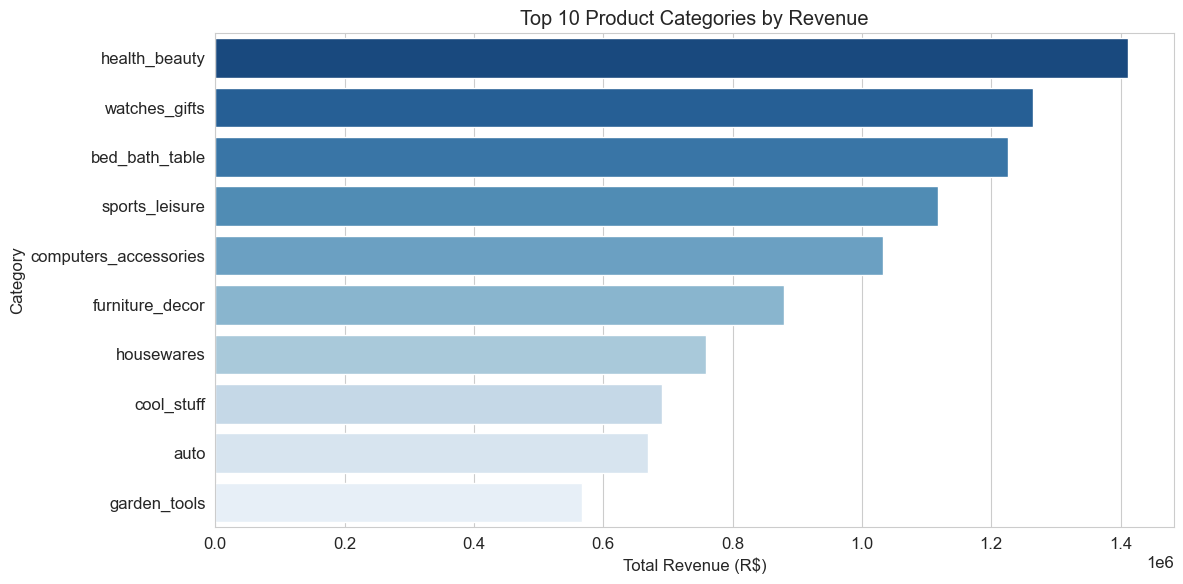

In [21]:
# Q: Which categories make the most money?


items_products = order_items.merge(products_clean[['product_id','product_category_name_english']], 
                                    on='product_id', how='left')
items_products = items_products.merge(
    master[['order_id']].drop_duplicates(), on='order_id', how='inner')

category_revenue = items_products.groupby(
    'product_category_name_english')['order_value'].sum().reset_index()
category_revenue = category_revenue.sort_values(
    'order_value', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, 
            x='order_value', y='product_category_name_english',hue='product_category_name_english',legend=False,
            palette='Blues_r')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

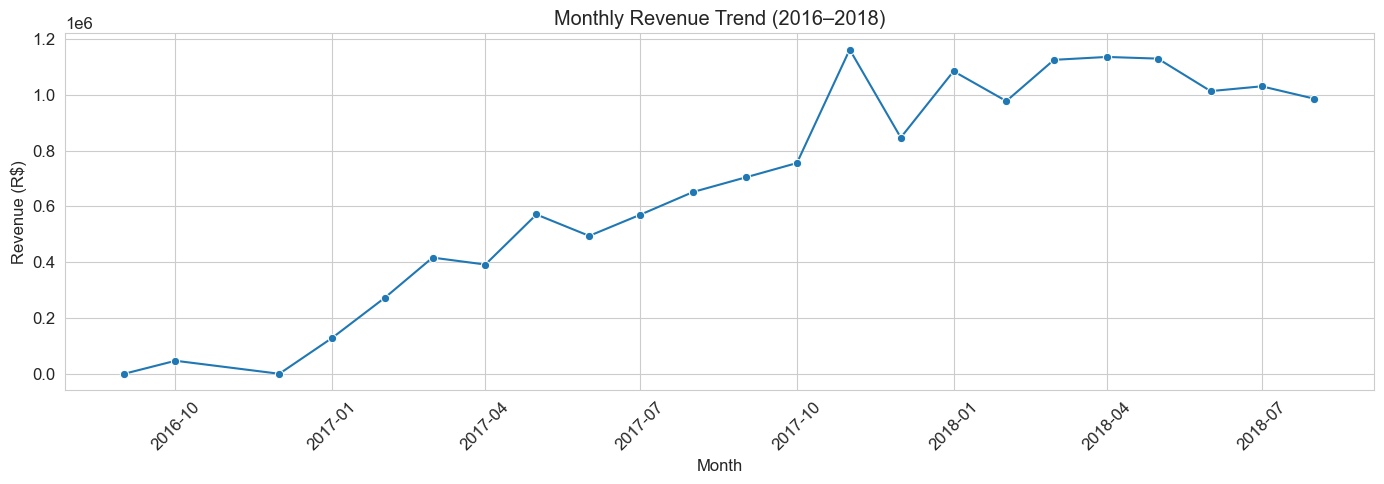

In [ ]:
# Q: How did revenue grow month by month?


monthly_revenue = master.groupby(
    ['order_year', 'order_month'])['revenue_per_order'].sum().reset_index()
monthly_revenue['period'] = pd.to_datetime(
    monthly_revenue['order_year'].astype(str) + '-' + 
    monthly_revenue['order_month'].astype(str) + '-01')

monthly_revenue = monthly_revenue.sort_values('period')

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='period', y='revenue_per_order', marker='o')
plt.title('Monthly Revenue Trend (2016–2018)')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

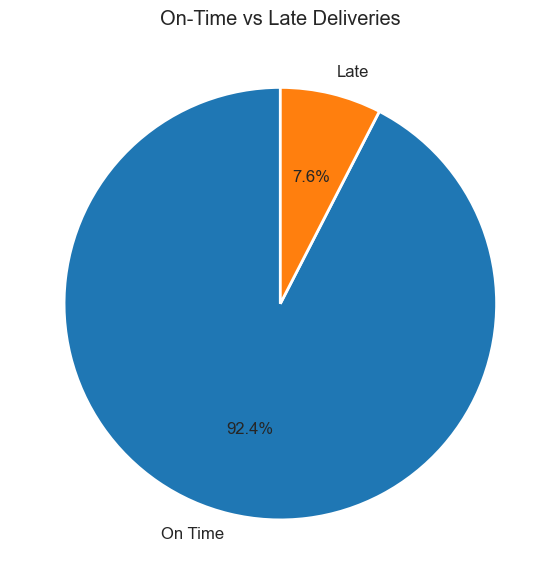

Total orders  : 97,007
On time       : 89,664
Late          : 7,343
Late %        : 7.6%


In [23]:
# Q: What % of orders were delivered late?

late_counts = master['is_late'].value_counts()
labels = ['On Time', 'Late']


plt.figure(figsize=(6, 6))
plt.pie(late_counts, labels=labels, autopct='%1.1f%%', 
        startangle=90, wedgeprops={'edgecolor':'white', 'linewidth':2})
plt.title('On-Time vs Late Deliveries')
plt.tight_layout()
plt.show()

print(f"Total orders  : {len(master):,}")
print(f"On time       : {(master['is_late']==0).sum():,}")
print(f"Late          : {(master['is_late']==1).sum():,}")
print(f"Late %        : {master['is_late'].mean()*100:.1f}%")

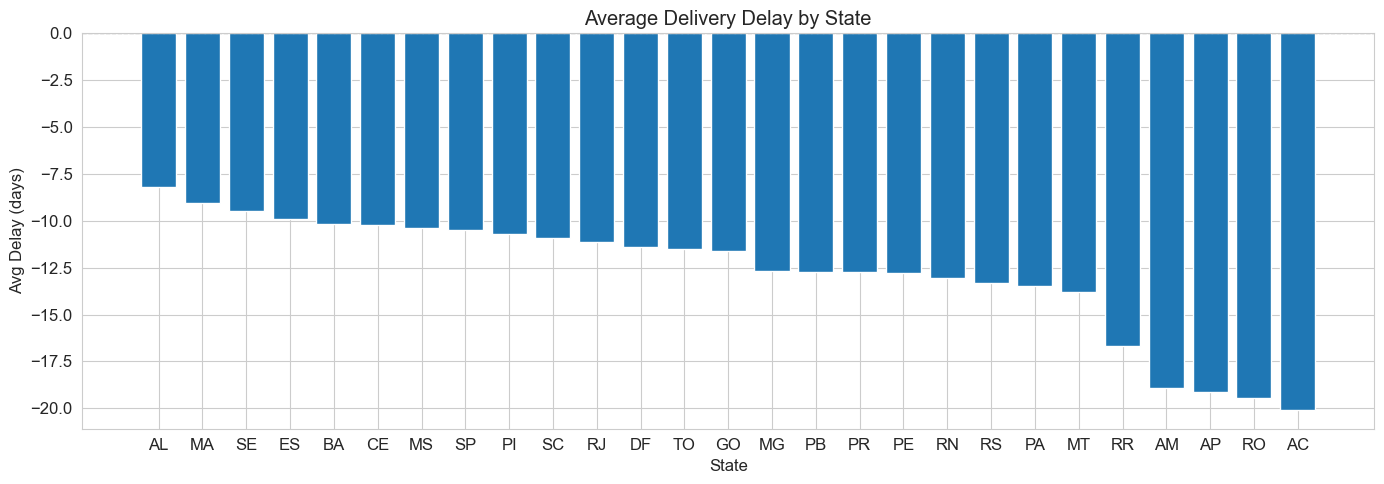

In [27]:
# Q: Which states have the worst delivery delays?


state_delay = master.groupby('customer_state')['delay_days'].mean().reset_index()
state_delay = state_delay.sort_values('delay_days', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(state_delay['customer_state'], state_delay['delay_days'])
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Average Delivery Delay by State')
plt.xlabel('State')
plt.ylabel('Avg Delay (days)')
plt.tight_layout()
plt.show()

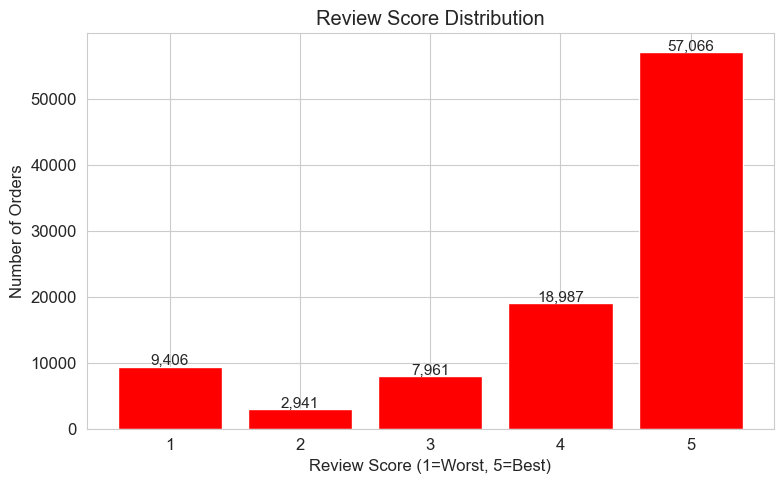

Average review score: 4.16 / 5


In [28]:
# Q: How satisfied are customers overall?

plt.figure(figsize=(8, 5))
score_counts = master['review_score'].value_counts().sort_index()
plt.bar(score_counts.index, score_counts.values, color='red', edgecolor='white')
plt.title('Review Score Distribution')
plt.xlabel('Review Score (1=Worst, 5=Best)')
plt.ylabel('Number of Orders')
for i, (score, count) in enumerate(score_counts.items()):
    plt.text(score, count + 200, f'{count:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Average review score: {master['review_score'].mean():.2f} / 5")

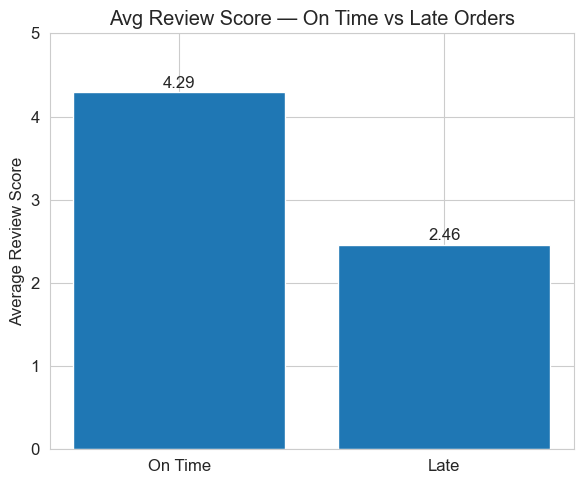

In [ ]:
# Q: Do late orders get worse reviews?

avg_score = master.groupby('is_late')['review_score'].mean().reset_index()
avg_score['label'] = avg_score['is_late'].map({0: 'On Time', 1: 'Late'})

plt.figure(figsize=(6, 5))
plt.bar(avg_score['label'], avg_score['review_score'])
plt.title('Avg Review Score — On Time vs Late Orders')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)

# Add labels above bars
for score, value in zip(avg_score['label'], avg_score['review_score']):
    plt.text(score, value + 0.05, f"{value:.2f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Export to SQL Server

from sqlalchemy import create_engine

# Connect to SQL Server
engine = create_engine(
    "mssql+pyodbc://KIRANMK\\KIRAN_MK/ols data"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

print("Connecting to SQL Server...")

# Test connection
with engine.connect() as conn:
    print(" Connected successfully")

Connecting to SQL Server...
✓ Connected successfully


C:\Users\mohan\AppData\Local\Temp\ipykernel_30628\1319032294.py:15: SAWarning: Unrecognized server version info '17.0.1105.2'.  Some SQL Server features may not function properly.
  with engine.connect() as conn:


In [48]:
#  Export all clean tables to SQL Server

tables_to_export = {
    'orders_clean'       : orders_clean,
    'order_items'        : order_items,
    'customers'          : customers,
    'sellers'            : sellers,
    'products_clean'     : products_clean,
    'order_payments'     : order_payments,
    'order_reviews_clean': order_reviews_clean,
    'geolocation'        : geo_location,
    'product_categories' : product_categories,
}

for table_name, df in tables_to_export.items():
    print(f"Exporting {table_name}... ({len(df):,} rows)")
    df.to_sql(
        name=table_name,
        con=engine,
        if_exists='replace',    # replace if table already exists
        index=False,            # don't write row numbers
        chunksize=1000          # push 1000 rows at a time
    )
    print(f"   Done")

print("\n All tables exported to SQL Server successfully")

Exporting orders_clean... (96,478 rows)
   Done
Exporting order_items... (112,650 rows)
   Done
Exporting customers... (99,441 rows)
   Done
Exporting sellers... (3,095 rows)
   Done
Exporting products_clean... (32,951 rows)
   Done
Exporting order_payments... (103,886 rows)
   Done
Exporting order_reviews_clean... (99,224 rows)
   Done
Exporting geolocation... (1,000,163 rows)
   Done
Exporting product_categories... (71 rows)
   Done

 All tables exported to SQL Server successfully
